In [10]:
import fig01, fig05to06
import matplotlib.pyplot as plt

# notebook defaults
plt.rcParams.update({"font.size": 12, "font.family": "Helvetica", "savefig.transparent": True})

In [11]:
# load + preprocess
df195 = fig01.preproc_df()

# print number of trials (single-line)
n_trials = df195["RT"].count()
trials_per_day = df195.groupby("day")["RT"].count()
trials_per_bin = df195.groupby("trial")["RT"].count()
print(
    f"n trials: {n_trials} \t n trials/day: mean={trials_per_day.mean():.1f}, std={trials_per_day.std():.1f} \t "
    f"n trials/bin: mean={trials_per_bin.mean():.1f}, std={trials_per_bin.std():.1f}"
)

n trials: 42840 	 n trials/day: mean=542.3, std=206.1 	 n trials/bin: mean=840.0, std=582.7


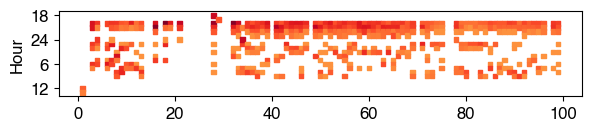

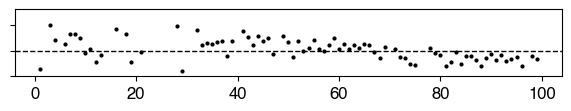

In [12]:
# day in study
hm_fitby_day = df195.query("trial > 0").groupby(["day", "hour"], as_index=False)["RT"].count()
fig, ax = plt.subplots(figsize=(5.8, 1.2), layout="constrained")
fig05to06.plot_heatmap(ax=ax, df=hm_fitby_day, fitby="day")

n_fitby_day = df195.query("trial > 0").groupby(["day"], as_index=False)["RT"].count()
fig, ax = plt.subplots(figsize=(5.6, 1), layout="constrained")
ax.scatter(n_fitby_day["day"], n_fitby_day["RT"], c="k", s=4)
ax.set(yticks=[0, 500, 1000], ylim=[0, 1300], yticklabels=[])
ax.axhline(500, ls="--", lw=1, c="k")

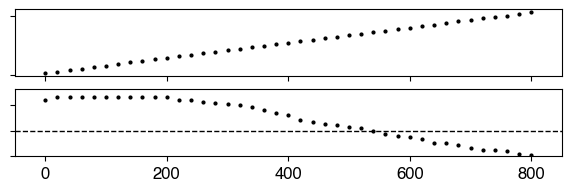

In [13]:
# trial in day
wsf_fitby_trial = df195.query("day > 35 and trial <= 800").groupby("trial")["reward"].mean().cumsum()
fig, axs = plt.subplots(nrows=2, figsize=(5.6, 1.8), layout="constrained", sharex=True)
axs[0].scatter(wsf_fitby_trial.index, wsf_fitby_trial.values, c="k", s=4)
axs[0].set(xlim=[-50, 850], xticks=[0, 200, 400, 600, 800], yticklabels=[])

n_fitby_trial = df195.query("day > 35 and trial <= 800").groupby(["trial"], as_index=False)["RT"].count()
axs[1].scatter(n_fitby_trial["trial"], n_fitby_trial["RT"], c="k", s=4)
axs[1].set(xlim=[-50, 850], xticks=[0, 200, 400, 600, 800], yticks=[0, 500, 1000], ylim=[0, 1300], yticklabels=[])
axs[1].axhline(500, ls="--", lw=1, c="k")

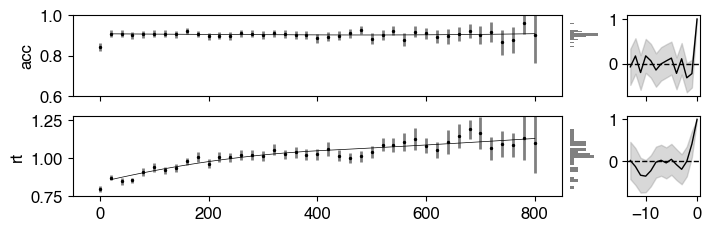

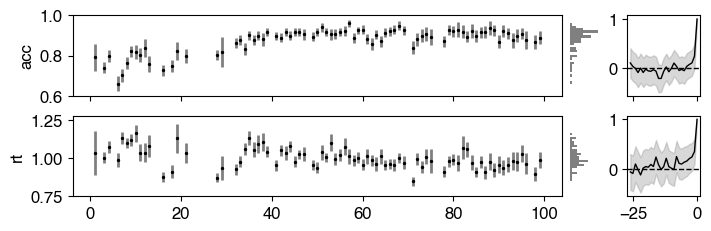

In [14]:
# fit and plot accuracy and reaction times

beh_fitby_trial = fig05to06.fit_beh(df=df195.query("day > 35 and trial <= 800"), fitby="trial")
beh_fitby_day = fig05to06.fit_beh(df=df195.query("trial > 0"), fitby="day")

formula = "bs(x, df=3, degree=2)"

fig, axs = plt.subplots(
    nrows=2, ncols=3, figsize=(7, 2.2), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig05to06.plot_estimates(axs=axs[0], df=beh_fitby_trial, fitby="trial", col="acc", formula=formula)
fig05to06.plot_estimates(axs=axs[1], df=beh_fitby_trial, fitby="trial", col="rt", formula=formula)

fig, axs = plt.subplots(
    nrows=2, ncols=3, figsize=(7, 2.2), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig05to06.plot_estimates(axs=axs[0], df=beh_fitby_day, fitby="day", col="acc", formula=formula)
fig05to06.plot_estimates(axs=axs[1], df=beh_fitby_day, fitby="day", col="rt", formula=formula)

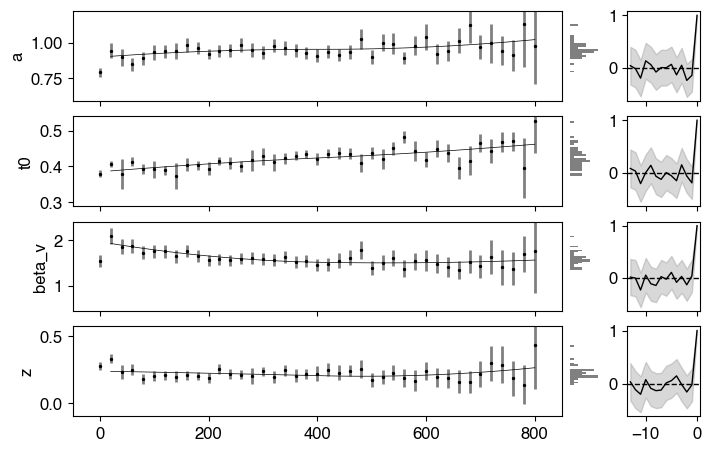

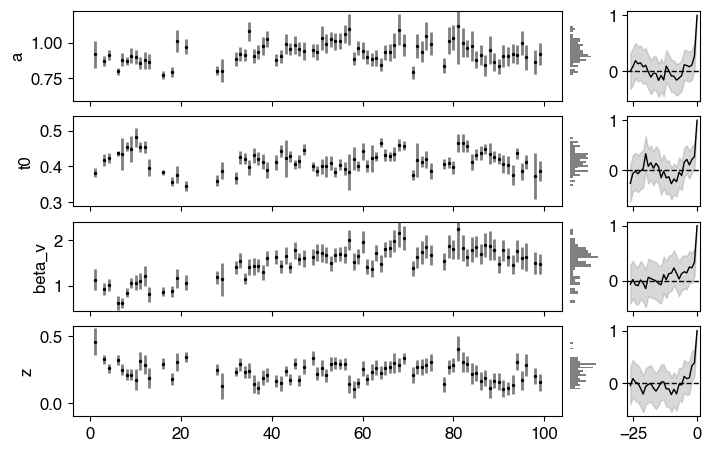

In [15]:
# !! specify whether to refit parameters !!
REFIT = False  # True to refit parameters, False to load precomputed results

# fit and plot DDM parameters
ddm_fitby_trial = fig05to06.fit_ddm(df=df195.query("day > 35 and trial <= 800"), fitby="trial", refit=REFIT)
ddm_fitby_day = fig05to06.fit_ddm(df=df195.query("trial > 0"), fitby="day", refit=REFIT)

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(7, 4.4), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig05to06.plot_estimates(axs=axs[0], df=ddm_fitby_trial, fitby="trial", col="a", formula=formula)
fig05to06.plot_estimates(axs=axs[1], df=ddm_fitby_trial, fitby="trial", col="t0", formula=formula)
fig05to06.plot_estimates(axs=axs[2], df=ddm_fitby_trial, fitby="trial", col="beta_v", formula=formula)
fig05to06.plot_estimates(axs=axs[3], df=ddm_fitby_trial, fitby="trial", col="z", formula=formula)

fig, axs = plt.subplots(
    nrows=4, ncols=3, figsize=(7, 4.4), width_ratios=[10, 0.6, 1.5], sharex="col", layout="constrained"
)
fig05to06.plot_estimates(axs=axs[0], df=ddm_fitby_day, fitby="day", col="a")
fig05to06.plot_estimates(axs=axs[1], df=ddm_fitby_day, fitby="day", col="t0")
fig05to06.plot_estimates(axs=axs[2], df=ddm_fitby_day, fitby="day", col="beta_v")
fig05to06.plot_estimates(axs=axs[3], df=ddm_fitby_day, fitby="day", col="z")